# Figure 1 and part of S3

## Import statements

In [38]:
import xarray as xr
import numpy as np
import pandas as pd
import json
import pickle
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
import pandas as pd
import cftime
import xesmf as xe
import pop_tools
import analysis_functions as afuncs

## Constants

In [10]:
# Constants
base_paths = {
    'linear':    '/glade/work/cmendiola/data_conv_lin_trend',
    'quadratic': '/glade/work/cmendiola/data_quad_trend',
    'ensmean':   '/glade/work/cmendiola/data_ens_mean',
    'noseas':    '/glade/work/cmendiola/data_rm_seasonalcycle_mean',
}
RADIUS_INDEX_FOR_2DEG = 1
OVERLAP_THRESHOLD_INDEX = 4  # 50%

## Functions

In [ ]:
def reload_subsurface_profiles(output_dir, n_members=100):
    profiles = {}
    for member_id in range(n_members):
        save_path = f'{output_dir}/member_{member_id}.pkl'
        if os.path.exists(save_path):
            with open(save_path, 'rb') as f:
                profiles.update(pickle.load(f))
    return profiles

In [ ]:
def phase_split_adaptive_subsurface(profile, pre_post_months=2, min_months_for_5phase=8):
    n_total = len(profile.time)
    core_start = pre_post_months
    core_end = n_total - pre_post_months
    core_length = core_end - core_start
    surface_series = profile.isel(z_t=0)

    if core_length < min_months_for_5phase:
        pre_mhw = profile.isel(time=slice(0, core_start)).mean(dim='time')
        detection = profile.isel(time=slice(core_start, core_end)).mean(dim='time')
        post_mhw = profile.isel(time=slice(-pre_post_months, None)).mean(dim='time')
        result = xr.concat([pre_mhw, detection, post_mhw], dim='phase').assign_coords(
            phase=['Pre-MHW', 'detection', 'Post-MHW'])
        return result, 3, None

    core_surface = surface_series.isel(time=slice(core_start, core_end))
    peak_idx_within_core = int(core_surface.values.argmax())
    peak_idx_global = core_start + peak_idx_within_core
    has_prepeak = peak_idx_global > core_start
    has_postpeak = peak_idx_global < core_end - 1

    pre_mhw = profile.isel(time=slice(0, core_start)).mean(dim='time')
    prepeak = profile.isel(time=slice(core_start, peak_idx_global)).mean(dim='time') if has_prepeak else xr.full_like(pre_mhw, np.nan)
    peak = profile.isel(time=peak_idx_global)
    postpeak = profile.isel(time=slice(peak_idx_global + 1, core_end)).mean(dim='time') if has_postpeak else xr.full_like(pre_mhw, np.nan)
    post_mhw = profile.isel(time=slice(-pre_post_months, None)).mean(dim='time')

    result = xr.concat([pre_mhw, prepeak, peak, postpeak, post_mhw], dim='phase').assign_coords(
        phase=['Pre-MHW', 'pre-peak', 'peak', 'post-peak', 'Post-MHW'])
    peak_date = profile.time.values[peak_idx_global]
    return result, 5, peak_date

In [ ]:
def compute_cell_area(grid_ref, R=6371.0):
    dlat = np.deg2rad(np.mean(np.diff(grid_ref.lat.values)))
    dlon = np.deg2rad(np.mean(np.diff(grid_ref.lon.values)))
    cell_area = (R ** 2) * dlat * dlon * np.cos(np.deg2rad(grid_ref.lat))
    return xr.DataArray(cell_area.values, coords={'lat': grid_ref.lat}, dims='lat')

In [34]:
def phase_split_adaptive(term_profiles, pre_post_months=2, min_months_for_5phase=8):
    """
    Splits an event's heat budget profile into either:
      - 3 phases (Pre-MHW, detection, Post-MHW) if core duration < min_months_for_5phase
      - 5 phases (Pre-MHW, pre-peak, peak-tendency, post-peak, Post-MHW) otherwise

    peak-tendency month = the month of maximum ABSOLUTE TEND_TEMP within the core
    detection window, i.e. maximum rate of change regardless of sign.
    """
    tend_temp = term_profiles['TEND_TEMP']
    n_total = len(tend_temp.time)
    core_start = pre_post_months
    core_end = n_total - pre_post_months
    core_length = core_end - core_start

    if core_length < min_months_for_5phase:
        result = {}
        for term, ts in term_profiles.items():
            result[term] = {
                'Pre-MHW':  float(ts.isel(time=slice(0, core_start)).mean()),
                'detection': float(ts.isel(time=slice(core_start, core_end)).mean()),
                'Post-MHW': float(ts.isel(time=slice(-pre_post_months, None)).mean()),
            }
        return result, 3, None

    core_tend = tend_temp.isel(time=slice(core_start, core_end))
    peak_idx_within_core = int(np.abs(core_tend.values).argmax())
    peak_idx_global = core_start + peak_idx_within_core
    has_prepeak = peak_idx_global > core_start
    has_postpeak = peak_idx_global < core_end - 1

    result = {}
    for term, ts in term_profiles.items():
        result[term] = {
            'Pre-MHW':  float(ts.isel(time=slice(0, core_start)).mean()),
            'pre-peak': float(ts.isel(time=slice(core_start, peak_idx_global)).mean()) if has_prepeak else np.nan,
            'peak-tendency': float(ts.isel(time=peak_idx_global)),
            'post-peak': float(ts.isel(time=slice(peak_idx_global + 1, core_end)).mean()) if has_postpeak else np.nan,
            'Post-MHW': float(ts.isel(time=slice(-pre_post_months, None)).mean()),
        }
    peak_date = tend_temp.time.values[peak_idx_global]
    return result, 5, peak_date

In [36]:
def detrend_term(da):
    term_nan = xr.where(da == 0., np.nan, da) * NO_SEC_IN_1_MON
    mean, trend, seasonal, notrend = afuncs.calculate_pop_grid_anomalies_trend_features(term_nan)
    return notrend

def build_padded_time_window(full_time_index, event_times, pre_post_months=2):
    first_idx = int(np.where(full_time_index.values == event_times.values[0])[0][0])
    last_idx = int(np.where(full_time_index.values == event_times.values[-1])[0][0])
    pad_start = max(0, first_idx - pre_post_months)
    pad_end = min(len(full_time_index) - 1, last_idx + pre_post_months)
    return full_time_index.isel(time=slice(pad_start, pad_end + 1))


## Load data

In [ ]:
mhwobj_paths = [f"{base_paths['linear']}/ens_{i}_mhwobj.nc" for i in range(100)]
da_mhwobj = xr.open_mfdataset(mhwobj_paths, combine='nested', concat_dim='ensemble_member')
labels_full = da_mhwobj.labels.sel(radius=RADIUS_INDEX_FOR_2DEG).sel(time=slice('1979-01', '2020-12')).compute()
print("Labels loaded:", labels_full.sizes)

In [ ]:
with open('object_id_ls_greenmask_linear_corrected.json', 'r') as f:
    linear_all_thresholds = json.load(f)
blob_analog_ids = {'linear': linear_all_thresholds[OVERLAP_THRESHOLD_INDEX]}
print(f"Total linear analogs: {sum(len(a) for a in blob_analog_ids['linear'])} -- VERIFY: 331")

In [ ]:
subsurface_155m = reload_subsurface_profiles('/glade/derecho/scratch/cassiacai/subsurface_profiles_by_member')
print(f"\nCanonical (155m) analogs loaded: {len(subsurface_155m)} -- VERIFY: 331")

subsurface_tv_deep = reload_subsurface_profiles('/glade/derecho/scratch/cassiacai/subsurface_profiles_by_member_timevarying_deeper')
print(f"Time-varying (236m) analogs loaded: {len(subsurface_tv_deep)} -- VERIFY: 331")

In [16]:
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels
object_id = 94.0
print("fosi_blobs loaded:", fosi_blobs.dims, fosi_blobs.shape)

fosi_blobs loaded: ('time', 'lat', 'lon') (504, 64, 81)


In [17]:
cell_area_da = compute_cell_area(labels_full)

mean_image_pop_files = [f'/glade/derecho/scratch/cassiacai/mean_image_{i}_POP.nc' for i in range(1, 8)]
mean_images_pop = [xr.open_dataset(file) for file in mean_image_pop_files]
masks_pop = [xr.where(image.__xarray_dataarray_variable__ > 0.1, 1, 0) for image in mean_images_pop]

canonical_area_km2 = float((cell_area_da * 0).sum())  # placeholder if mask isn't on labels grid yet

## Checks

In [1]:
# Population-level canonical vs. time-varying SURFACE SSTa
print("\n=== Check 2: Canonical vs. time-varying surface SSTa ===")
canon_surface_mean, canon_surface_max = [], []
tv_surface_mean, tv_surface_max = [], []

shared_keys_surface = [k for k in subsurface_155m if k in subsurface_tv_deep]

for key in shared_keys_surface:
    canon_surface = subsurface_155m[key]['profile'].isel(z_t=0)
    tv_surface = subsurface_tv_deep[key]['profile'].isel(z_t=0)
    canon_surface_mean.append(float(canon_surface.mean()))
    canon_surface_max.append(float(canon_surface.max()))
    tv_surface_mean.append(float(tv_surface.mean()))
    tv_surface_max.append(float(tv_surface.max()))

canon_surface_mean = np.array(canon_surface_mean)
canon_surface_max = np.array(canon_surface_max)
tv_surface_mean = np.array(tv_surface_mean)
tv_surface_max = np.array(tv_surface_max)

ratio_mean = tv_surface_mean / canon_surface_mean
ratio_max = tv_surface_max / canon_surface_max

print(f"n = {len(shared_keys_surface)}")
print(f"Mean SSTa: canonical={canon_surface_mean.mean():.2f}±{canon_surface_mean.std():.2f}°C, "
      f"time-varying={tv_surface_mean.mean():.2f}±{tv_surface_mean.std():.2f}°C")
print(f"Ratio (time-varying/canonical), mean SSTa: {ratio_mean.mean():.2f}±{ratio_mean.std():.2f}")
print(f"Max SSTa: canonical={canon_surface_max.mean():.2f}±{canon_surface_max.std():.2f}°C, "
      f"time-varying={tv_surface_max.mean():.2f}±{tv_surface_max.std():.2f}°C")
print(f"Ratio (time-varying/canonical), max SSTa: {ratio_max.mean():.2f}±{ratio_max.std():.2f}")
print(f"Analogs where time-varying > canonical (mean): {100*np.mean(ratio_mean > 1):.1f}%")

canonical_phase_profiles_5 = {}
for key, data in subsurface_155m.items():
    result, n_phases, peak_date = phase_split_adaptive_subsurface(data['profile'])
    if n_phases == 5:
        canonical_phase_profiles_5[key] = result
canonical_composite = xr.concat(list(canonical_phase_profiles_5.values()), dim='analog').mean(dim='analog')

tv_phase_profiles_5 = {}
for key, data in subsurface_tv_deep.items():
    result, n_phases, peak_date = phase_split_adaptive_subsurface(data['profile'])
    if n_phases == 5:
        tv_phase_profiles_5[key] = result
tv_composite = xr.concat(list(tv_phase_profiles_5.values()), dim='analog').mean(dim='analog')

print(f"\nCanonical 5-phase: {len(canonical_phase_profiles_5)}, Time-varying 5-phase: {len(tv_phase_profiles_5)}")

Labels loaded: Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81})
Total linear analogs: 331 -- VERIFY: 331

=== Check 1: Near-miss temporal splits ===
Analogs with a high-overlap, short-gap neighboring object: 7 / 331

Canonical (155m) analogs loaded: 331 -- VERIFY: 331
Time-varying (236m) analogs loaded: 331 -- VERIFY: 331

=== Check 2: Canonical vs. time-varying surface SSTa ===
n = 331
Mean SSTa: canonical=0.55±0.15°C, time-varying=1.01±0.14°C
Ratio (time-varying/canonical), mean SSTa: 2.00±0.75
Max SSTa: canonical=1.09±0.22°C, time-varying=1.44±0.20°C
Ratio (time-varying/canonical), max SSTa: 1.35±0.23
Analogs where time-varying > canonical (mean): 100.0%

Canonical 5-phase: 242, Time-varying 5-phase: 242

=== Canonical vs. time-varying surface SSTa, by phase ===
  Pre-MHW: canonical=0.26°C, time-varying=0.61°C, ratio=2.30
  pre-peak: canonical=0.64°C, time-varying=1.17°C, ratio=1.82
  peak: canonical=1.13°C, time-varying=1.46°C, ratio=1.29
  post-peak: canonical=0

## Examining the Blob

### Functions for this section

In [11]:
def get_var_paths(directory, var):
    import os
    prefixes_to_match_fut = ['b.e21.BSSP370cmip6.', 'b.e21.BSSP370smbb.']
    prefixes_to_match_hist = ['b.e21.BHISTcmip6.', 'b.e21.BHISTsmbb.']
    prefixes_fut, prefixes_hist = [], []
    for filename in os.listdir(directory):
        if any(filename.startswith(p) for p in prefixes_to_match_fut) and filename.endswith('.nc'):
            prefixes_fut.append(filename.rsplit('.', 3)[0])
        if any(filename.startswith(p) for p in prefixes_to_match_hist) and filename.endswith('.nc'):
            prefixes_hist.append(filename.rsplit('.', 3)[0])
    return sorted(set(prefixes_hist)), sorted(set(prefixes_fut))

def find_identifier_with_index(prefixes, identifier):
    return [(p, i) for i, p in enumerate(prefixes) if identifier in p]

def get_hist_file_paths(var, directory, path_intermed_hist, index):
    attrib_title = path_intermed_hist[index]
    file_paths = [f'{directory}{attrib_title}.{var}.{y}01-{y+9}12.nc' for y in range(1850, 2010, 10)]
    file_paths.append(f'{directory}{attrib_title}.{var}.201001-201412.nc')
    return file_paths

def get_fut_file_paths(var, directory, path_intermed_fut, index):
    attrib_title = path_intermed_fut[index]
    file_paths = [f'{directory}{attrib_title}.{var}.{y}01-{y+9}12.nc' for y in range(2015, 2095, 10)]
    file_paths.append(f'{directory}{attrib_title}.{var}.209501-210012.nc')
    return file_paths

def file_path_to_var_ds(file_paths):
    return xr.open_mfdataset(file_paths, concat_dim='time', combine='nested', parallel=True)

def get_ds_var(directory, var, comp, index_hist):
    path_intermed_hist, path_intermed_fut = get_var_paths(directory, var)
    filename_identifier = '.'.join(path_intermed_hist[index_hist].rsplit('.', 5)[1:4])
    index_fut = find_identifier_with_index(path_intermed_hist, filename_identifier)[0][1]
    hist_file_paths = get_hist_file_paths(var, directory, path_intermed_hist, index_hist)
    fut_file_paths = get_fut_file_paths(var, directory, path_intermed_fut, index_fut)
    return file_path_to_var_ds(hist_file_paths), file_path_to_var_ds(fut_file_paths)

In [12]:
def regrid_SMYLE(ds, glat=1, glon=1):
    ds = ds.rename({'TLONG': 'lon', 'TLAT': 'lat'})
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

In [13]:
def calculate_anomalies_trend_features_4d(ds):
    dyr = ds.time.dt.year + ds.time.dt.month / 12
    model = np.array([
        np.ones(len(dyr)), dyr - np.mean(dyr),
        np.sin(2*np.pi*dyr), np.cos(2*np.pi*dyr),
        np.sin(4*np.pi*dyr), np.cos(4*np.pi*dyr)
    ])
    pmodel = np.linalg.pinv(model)
    model_da = xr.DataArray(model.T, dims=['time', 'coeff'], coords={'time': ds.time, 'coeff': np.arange(1, 7)})
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff', 'time'], coords={'coeff': np.arange(1, 7), 'time': ds.time})
    coeffs = xr.dot(pmodel_da, ds)
    full_model = model_da.dot(coeffs)
    ssta_notrend = ds - full_model
    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1, 'z_t': -1})
    return None, None, None, None, ssta_notrend

In [14]:
def depth_of_reach_at_time(profile, time_idx, threshold):
    """Depth (m) of deepest exceedance at a SINGLE timestep."""
    slice_ = profile.isel(time=time_idx)
    exceeds = slice_ > threshold
    if not exceeds.any():
        return np.nan
    return float(slice_.z_t.where(exceeds, drop=True).max()) / 100

### Analysis

In [18]:
# Blob's own tracked footprint area, per month (in km^2, not gridpoints)
object_id = 94.0
blob_mask_all_months = (fosi_blobs == object_id)
blob_times = fosi_blobs.time.where(blob_mask_all_months.any(dim=('lat', 'lon')), drop=True)

blob_area_by_month_km2 = []
for t in blob_times.values:
    month_mask = fosi_blobs.sel(time=t) == object_id
    area_km2 = float((month_mask.astype(int) * cell_area_da).sum())
    blob_area_by_month_km2.append(area_km2)

blob_area_by_month_km2 = np.array(blob_area_by_month_km2)

print(f"\nBlob's tracked footprint area, min={blob_area_by_month_km2.min():,.0f} km^2, "
      f"max={blob_area_by_month_km2.max():,.0f} km^2")
print(f"Canonical footprint area: 18,166,561 km^2 (confirmed earlier this session)")

n_smaller_than_canonical = np.sum(blob_area_by_month_km2 < 18_166_561)
print(f"\nMonths where tracked footprint < canonical footprint: {n_smaller_than_canonical} / {len(blob_area_by_month_km2)}")
print(f"Months where tracked footprint > canonical footprint: {len(blob_area_by_month_km2) - n_smaller_than_canonical} / {len(blob_area_by_month_km2)}")

print("\nMonth-by-month comparison:")
for i, (t, area) in enumerate(zip(blob_times.values, blob_area_by_month_km2)):
    comparison = "smaller" if area < 18_166_561 else "LARGER"
    print(f"  Month {i} ({str(t)[:7]}): tracked={area:,.0f} km^2 ({comparison} than canonical)")


Blob's tracked footprint area, min=2,966,349 km^2, max=24,261,031 km^2
Canonical footprint area: 18,166,561 km^2 (confirmed earlier this session)

Months where tracked footprint < canonical footprint: 15 / 20
Months where tracked footprint > canonical footprint: 5 / 20

Month-by-month comparison:
  Month 0 (2014-05): tracked=4,805,895 km^2 (smaller than canonical)
  Month 1 (2014-06): tracked=4,483,857 km^2 (smaller than canonical)
  Month 2 (2014-07): tracked=2,966,349 km^2 (smaller than canonical)
  Month 3 (2014-08): tracked=6,805,099 km^2 (smaller than canonical)
  Month 4 (2014-09): tracked=14,638,262 km^2 (smaller than canonical)
  Month 5 (2014-10): tracked=10,749,359 km^2 (smaller than canonical)
  Month 6 (2014-11): tracked=6,868,391 km^2 (smaller than canonical)
  Month 7 (2014-12): tracked=6,097,326 km^2 (smaller than canonical)
  Month 8 (2015-01): tracked=9,437,339 km^2 (smaller than canonical)
  Month 9 (2015-02): tracked=16,049,485 km^2 (smaller than canonical)
  Month 

In [19]:
canon_surface_mean, canon_surface_max = [], []
tv_surface_mean, tv_surface_max = [], []

shared_keys_surface = [k for k in subsurface_155m if k in subsurface_tv_deep]

for key in shared_keys_surface:
    canon_surface = subsurface_155m[key]['profile'].isel(z_t=0)
    tv_surface = subsurface_tv_deep[key]['profile'].isel(z_t=0)
    canon_surface_mean.append(float(canon_surface.mean()))
    canon_surface_max.append(float(canon_surface.max()))
    tv_surface_mean.append(float(tv_surface.mean()))
    tv_surface_max.append(float(tv_surface.max()))

canon_surface_mean = np.array(canon_surface_mean)
canon_surface_max = np.array(canon_surface_max)
tv_surface_mean = np.array(tv_surface_mean)
tv_surface_max = np.array(tv_surface_max)

ratio_mean = tv_surface_mean / canon_surface_mean
ratio_max = tv_surface_max / canon_surface_max

print(f"n = {len(shared_keys_surface)}")
print(f"Ratio (time-varying/canonical), mean SSTa: {ratio_mean.mean():.2f}±{ratio_mean.std():.2f}")
print(f"Analogs where time-varying > canonical (mean): {100*np.mean(ratio_mean > 1):.1f}%")

n = 331
Ratio (time-varying/canonical), mean SSTa: 2.00±0.75
Analogs where time-varying > canonical (mean): 100.0%


In [20]:
phase_names_5 = ['Pre-MHW', 'pre-peak', 'peak', 'post-peak', 'Post-MHW']
for phase in phase_names_5:
    canon_val = float(canonical_composite.isel(z_t=0).sel(phase=phase))
    tv_val = float(tv_composite.isel(z_t=0).sel(phase=phase))
    ratio = tv_val / canon_val if canon_val != 0 else np.nan
    print(f"  {phase}: canonical={canon_val:.2f}°C, time-varying={tv_val:.2f}°C, ratio={ratio:.2f}")

  Pre-MHW: canonical=0.26°C, time-varying=0.61°C, ratio=2.30
  pre-peak: canonical=0.64°C, time-varying=1.17°C, ratio=1.82
  peak: canonical=1.13°C, time-varying=1.46°C, ratio=1.29
  post-peak: canonical=0.62°C, time-varying=1.16°C, ratio=1.89
  Post-MHW: canonical=0.21°C, time-varying=0.60°C, ratio=2.81


In [21]:
blob_mask_all_months = (fosi_blobs == object_id)
blob_times = fosi_blobs.time.where(blob_mask_all_months.any(dim=('lat', 'lon')), drop=True)

blob_area_by_month_km2 = []
for t in blob_times.values:
    month_mask = fosi_blobs.sel(time=t) == object_id
    area_km2 = float((month_mask.astype(int) * cell_area_da).sum())
    blob_area_by_month_km2.append(area_km2)

blob_area_by_month_km2 = np.array(blob_area_by_month_km2)
n_smaller_than_canonical = np.sum(blob_area_by_month_km2 < 18_166_561)
print(f"Months where tracked footprint < canonical footprint: {n_smaller_than_canonical} / {len(blob_area_by_month_km2)}")

Months where tracked footprint < canonical footprint: 15 / 20


In [22]:
var, comp = 'SST', 'atm'
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
ds_var_hist_SST, ds_var_fut_SST = get_ds_var(directory, 'SST', 'atm', 0)
CESMLENS_SST = xr.concat([
    ds_var_hist_SST.SST.sel(time=slice('1979-01-01', '2015-01-01')),
    ds_var_fut_SST.SST.sel(time=slice('2015-02-01', '2020-12-01'))
], dim='time').compute()

# --- Canonical mask + FOSI Blob labels ---
mask_3 = xr.open_dataset('mean_mask_3.nc').mhw_obj
mhw_obj_mask = xr.where(mask_3 > 0.1, 1, 0)
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc')
object_id = 94.0
firstyear, lastyear = 1979, 2020

grid = pop_tools.get_grid('POP_gx1v7')
region_mask = xr.where((grid['REGION_MASK'] > 0) & (grid['REGION_MASK'] < 9), 1, np.nan)

# --- Load FOSI raw 3D TEMP ---
field = 'TEMP'
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi_temp = xr.open_dataset(fpath + fname)[field].isel(z_t=slice(0, 20))
fosi_montime_vals = [cftime.DatetimeNoLeap(1958 + year, 1 + month, 15) for year in range(63) for month in range(12)]
ds_smyle_fosi_temp['time'] = fosi_montime_vals

# --- Regrid: POP curvilinear -> 1deg -> CESMLENS_SST grid ---
fosi_anom_1deg_wzeros_temp = regrid_SMYLE(ds_smyle_fosi_temp)
fosi_anom_1deg_temp = fosi_anom_1deg_wzeros_temp.where(fosi_anom_1deg_wzeros_temp != 0, np.nan)

regridder_temp = xe.Regridder(
    fosi_anom_1deg_temp.sel(time=slice('1979-01-01', '2020-12-01')),
    CESMLENS_SST, 'nearest_s2d', periodic=True
)
regridded_temp = regridder_temp(fosi_anom_1deg_temp.sel(time=slice('1979-01-01', '2020-12-01')))

# --- Crop, detrend/deseasonalize ---
smaller_region_temp = regridded_temp.sel(lat=slice(12, 65), lon=slice(155, 245))
_, _, _, _, anomalies = calculate_anomalies_trend_features_4d(smaller_region_temp)

smaller_mhw_obj_mask = mhw_obj_mask.sel(lat=slice(12, 65), lon=slice(155, 245))
fosi_blobs_cropped = fosi_blobs.labels.sel(lat=slice(12, 65), lon=slice(155, 245))

blob_times = fosi_blobs_cropped.time.where((fosi_blobs_cropped == object_id).any(dim=('lat', 'lon')), drop=True)
full_time_index = anomalies.time
first_idx = int(np.where(full_time_index.values == blob_times.values[0])[0][0])
last_idx = int(np.where(full_time_index.values == blob_times.values[-1])[0][0])
pad_start = max(0, first_idx - 2)
pad_end = min(len(full_time_index) - 1, last_idx + 2)
padded_times = full_time_index.isel(time=slice(pad_start, pad_end + 1))

canonical_masked = anomalies.sel(time=padded_times).where(smaller_mhw_obj_mask == 1)
canonical_profile = canonical_masked.mean(dim=('lat', 'lon')).compute()

print("canonical_profile rebuilt:", canonical_profile.dims, canonical_profile.shape)

/glade/derecho/scratch/cassiacai/tmp/ipykernel_49348/3137719365.py:23: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_smyle_fosi_temp = xr.open_dataset(fpath + fname)[field].isel(z_t=slice(0, 20))


canonical_profile rebuilt: ('time', 'z_t') (24, 20)


In [23]:
thresholds = [0.5, 0.75, 1.0]

# canonical_profile is the FOSI Blob's canonical-footprint subsurface profile (time, z_t)
print("=== FOSI Blob: depth of warming reach over time, canonical footprint ===")
for threshold in thresholds:
    depths_over_time = [depth_of_reach_at_time(canonical_profile, i, threshold)
                         for i in range(len(canonical_profile.time))]
    print(f"\n{threshold}°C threshold:")
    for i, (t, d) in enumerate(zip(canonical_profile.time.values, depths_over_time)):
        print(f"  Month {i} ({str(t)[:7]}): {d:.1f}m" if not np.isnan(d) else f"  Month {i} ({str(t)[:7]}): no exceedance")

=== FOSI Blob: depth of warming reach over time, canonical footprint ===

0.5°C threshold:
  Month 0 (2014-03): no exceedance
  Month 1 (2014-04): no exceedance
  Month 2 (2014-05): 25.0m
  Month 3 (2014-06): 35.0m
  Month 4 (2014-07): no exceedance
  Month 5 (2014-08): 25.0m
  Month 6 (2014-09): 35.0m
  Month 7 (2014-10): 55.0m
  Month 8 (2014-11): 75.0m
  Month 9 (2014-12): 85.0m
  Month 10 (2015-01): 65.0m
  Month 11 (2015-02): 95.0m
  Month 12 (2015-03): 105.0m
  Month 13 (2015-04): 105.0m
  Month 14 (2015-05): 115.0m
  Month 15 (2015-06): 115.0m
  Month 16 (2015-07): 105.0m
  Month 17 (2015-08): 105.0m
  Month 18 (2015-09): 115.0m
  Month 19 (2015-10): 115.0m
  Month 20 (2015-11): 85.0m
  Month 21 (2015-12): 115.0m
  Month 22 (2016-01): 125.0m
  Month 23 (2016-02): 135.0m

0.75°C threshold:
  Month 0 (2014-03): no exceedance
  Month 1 (2014-04): no exceedance
  Month 2 (2014-05): no exceedance
  Month 3 (2014-06): no exceedance
  Month 4 (2014-07): no exceedance
  Month 5 (2014-08

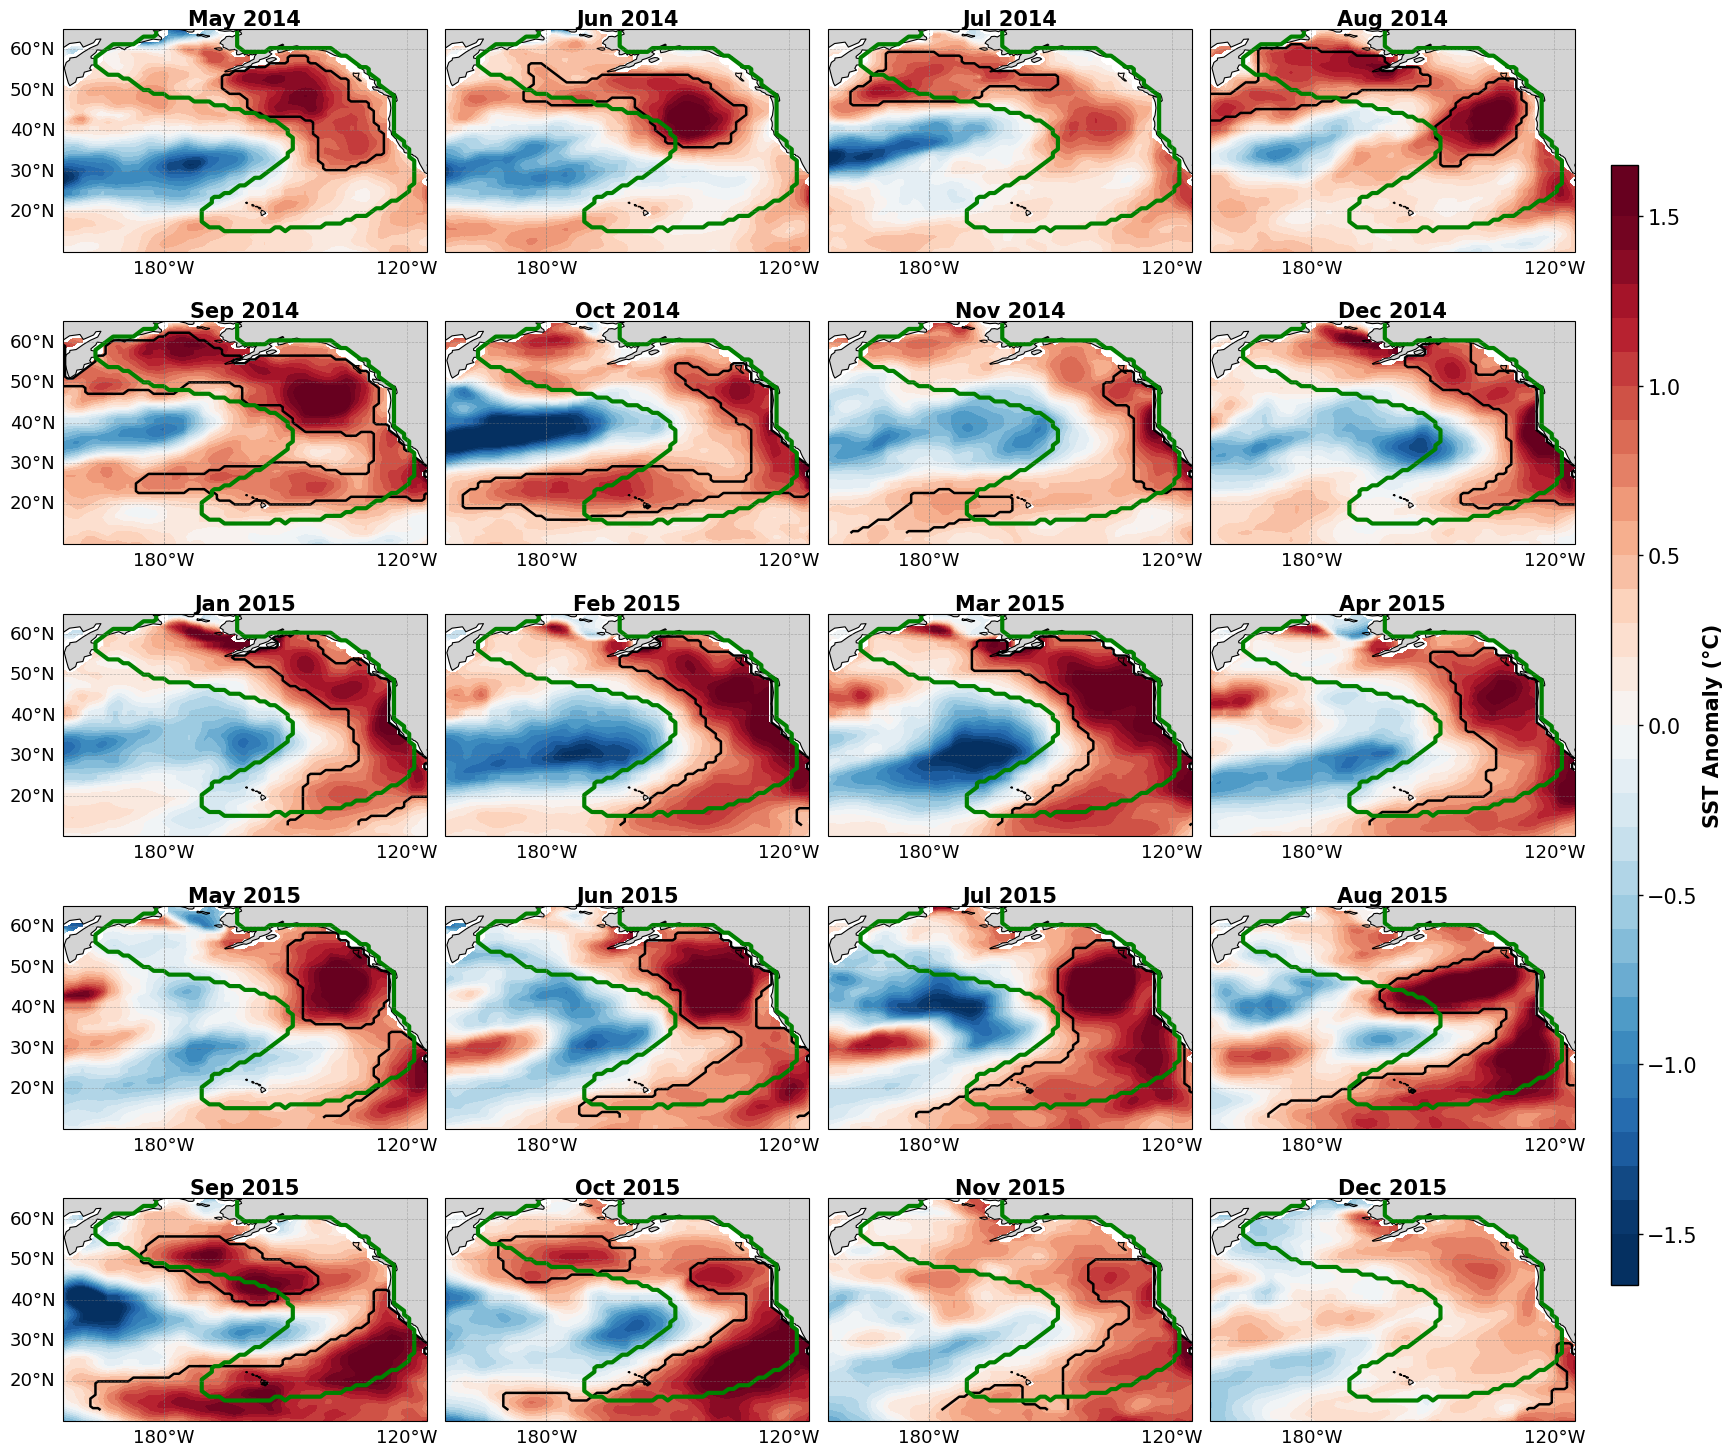

In [25]:
# Detrended + deseasonalized surface SSTa, for map panel (a)
surface_temp = regridded_temp.isel(z_t=0)  # surface level, full record
_, _, _, _, ssta_detrended = calculate_anomalies_trend_features_4d(surface_temp)

# Panel (a): 5x4 grid of monthly maps, May 2014-Dec 2015
months_to_plot = pd.date_range('2014-05-01', '2015-12-01', freq='MS')
n_months = len(months_to_plot)

fig, axes = plt.subplots(5, 4, figsize=(18, 16),
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
                         gridspec_kw={'hspace': 0.08, 'wspace': 0.05})
axes = axes.flatten()

levels = np.linspace(-1.5, 1.5, 31)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for idx, (ax, month_start) in enumerate(zip(axes, months_to_plot)):
    target_year, target_month = month_start.year, month_start.month
    time_matches = [t for t in ssta_detrended.time.values if t.year == target_year and t.month == target_month]
    if not time_matches:
        continue
    t_match = time_matches[0]
    ssta_slice = ssta_detrended.sel(time=t_match)

    im = ax.contourf(ssta_slice.lon, ssta_slice.lat, ssta_slice.values,
                      levels=levels, cmap='RdBu_r', extend='both',
                      transform=ccrs.PlateCarree())

    blob_mask_month = (fosi_blobs_cropped.sel(time=t_match) == object_id).astype(int)
    ax.contour(blob_mask_month.lon, blob_mask_month.lat, blob_mask_month.values,
               levels=[0.5], colors='black', linewidths=1.8, transform=ccrs.PlateCarree())

    ax.contour(smaller_mhw_obj_mask.lon, smaller_mhw_obj_mask.lat, smaller_mhw_obj_mask.values,
               levels=[0.5], colors='green', linewidths=3.0, transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none')
    ax.coastlines(linewidth=0.8, color='black')

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (idx % 4 == 0)
    gl.bottom_labels = True
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 13, 'color': 'black'}
    gl.ylabel_style = {'size': 13, 'color': 'black'}

    ax.set_extent([155, 245, 10, 65], crs=ccrs.PlateCarree())

    title_str = f"{month_names[target_month-1]} {target_year}"
    ax.set_title(title_str, fontsize=15, fontweight='bold', pad=2)

for ax in axes[n_months:]:
    ax.set_visible(False)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax, label='SST Anomaly (°C)',
                    extend='both', extendrect=True, ticks=np.arange(-1.5, 1.6, 0.5))
cbar.ax.tick_params(labelsize=15, colors='black', width=1)
cbar.set_label('SST Anomaly (°C)', fontsize=15, fontweight='bold')
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)

plt.subplots_adjust(left=0.06, right=0.90, bottom=0.05, top=0.95)
plt.savefig('Figure1a_monthly_maps.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# Rebuild FOSI MLD (HMXL), regridded and cropped, for panel (b)
field = 'HMXL'
fname_mld = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi_hxml = xr.open_dataset(fpath + fname_mld)[field]
ds_smyle_fosi_hxml['time'] = fosi_montime_vals
fosi_mld = ds_smyle_fosi_hxml[
    ds_smyle_fosi_hxml.time['time.year'].isin(list(range(firstyear, lastyear + 1)))
].where(region_mask == 1, np.nan)

fosi_anom_1deg_wzeros_mld = regrid_SMYLE(fosi_mld)
fosi_anom_1deg_mld = fosi_anom_1deg_wzeros_mld.where(fosi_anom_1deg_wzeros_mld != 0, np.nan)

regridder_mld = xe.Regridder(
    fosi_anom_1deg_mld.sel(time=slice('1979-01-01', '2021-01-01')),
    CESMLENS_SST, 'nearest_s2d', periodic=True
)
regridded_mld = regridder_mld(fosi_anom_1deg_mld.sel(time=slice('1979-01-01', '2021-01-01')))
smaller_region_mld = regridded_mld.sel(lat=slice(12, 65), lon=slice(155, 245))

print("smaller_region_mld rebuilt:", smaller_region_mld.dims, smaller_region_mld.shape)

/glade/derecho/scratch/cassiacai/tmp/ipykernel_49348/2177619479.py:4: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_smyle_fosi_hxml = xr.open_dataset(fpath + fname_mld)[field]


smaller_region_mld rebuilt: ('time', 'lat', 'lon') (504, 56, 73)


In [27]:
# Full-record (2011-2020) canonical-footprint subsurface profile
full_range_times = anomalies.time.where(
    (anomalies.time.dt.year >= 2011) & (anomalies.time.dt.year <= 2020), drop=True
)
canonical_profile_full = anomalies.sel(time=full_range_times).where(smaller_mhw_obj_mask == 1).mean(dim=('lat', 'lon')).compute()

# MLD, same full range (reuse smaller_region_mld from earlier FOSI MLD pipeline)
canonical_mld_profile_full = (
    smaller_region_mld.sel(time=full_range_times).where(smaller_mhw_obj_mask == 1).mean(dim=('lat', 'lon')) / 100
).compute()

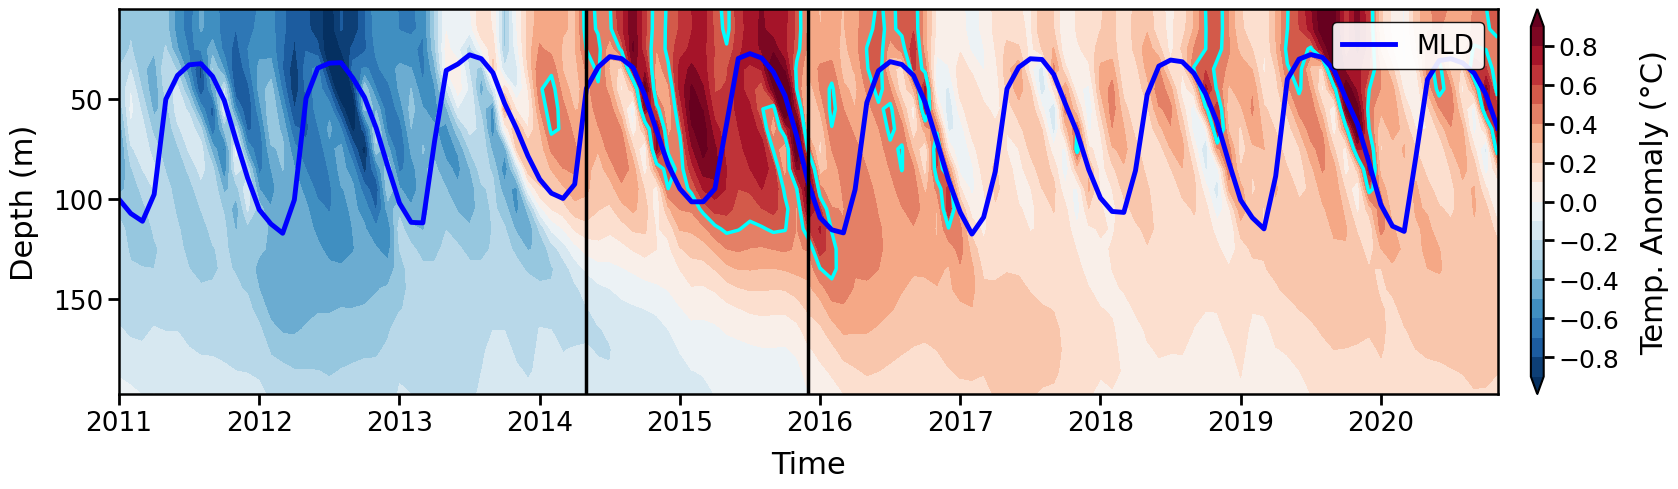

In [28]:
fig, ax = plt.subplots(figsize=(18, 5))

depth_m = canonical_profile_full.z_t.values / 100
time_vals = canonical_profile_full.time.values
x_numeric = np.arange(len(time_vals))

levels = np.linspace(-0.9, 0.9, 19)
im = ax.contourf(x_numeric,depth_m,canonical_profile_full.values.T,levels=levels,cmap='RdBu_r',extend='both')

# +0.5°C contour
ax.contour(x_numeric,depth_m,canonical_profile_full.values.T,levels=[0.5],colors='cyan',linewidths=2.5)

# Mixed Layer Depth
ax.plot(x_numeric,canonical_mld_profile_full.values,color='blue',linewidth=3.5,label='MLD')

# Blob start/end
blob_start_idx = int(np.where(time_vals == blob_times.values[0])[0][0])
blob_end_idx = int(np.where(time_vals == blob_times.values[-1])[0][0])
ax.axvline(blob_start_idx,color='black',linewidth=2.5)
ax.axvline(blob_end_idx,color='black',linewidth=2.5)
ax.invert_yaxis()

year_ticks = [i for i, t in enumerate(time_vals) if t.month == 1]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(time_vals[i].year) for i in year_ticks],fontsize=20,)
ax.set_xlabel('Time',fontsize=22,labelpad=10)
ax.set_ylabel('Depth (m)',fontsize=22,labelpad=10)
ax.tick_params(axis='both',which='major',labelsize=19,width=2,length=8)
ax.tick_params(axis='both',which='minor',width=1.5,length=5)

# Legend
ax.legend(loc='upper right',fontsize=19,frameon=True,framealpha=0.9,edgecolor='black')

# Colorbar
cbar = fig.colorbar(im,ax=ax,pad=0.02,aspect=30)
cbar.set_label('Temp. Anomaly (°C)',fontsize=22,labelpad=15)
cbar.ax.tick_params(labelsize=18,width=2,length=7)

cbar.outline.set_linewidth(1.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.8)
plt.tight_layout()
plt.show()

In [29]:
lat_slice = slice(204, 367)
lon_slice = slice(190, 280)
NO_SEC_IN_1_MON = 2629740

def detrend_term(da):
    import analysis_functions as afuncs
    term_nan = xr.where(da == 0., np.nan, da) * NO_SEC_IN_1_MON
    mean, trend, seasonal, notrend = afuncs.calculate_pop_grid_anomalies_trend_features(term_nan)
    return notrend

fosi_heat_budget = xr.open_dataset('/glade/derecho/scratch/cassiacai/fosi_heat_budget_155m.nc')
fosi_heat_budget['SUBGRID'] = fosi_heat_budget['TEND_TEMP'] - (
    fosi_heat_budget['TOTADV'] + fosi_heat_budget['SHF_depth'] + fosi_heat_budget['QSW_3D']
)

fosi_hb_detrended = {}
for term in ['TOTADV', 'SHF_depth', 'QSW_3D', 'SUBGRID', 'TEND_TEMP']:
    notrend = detrend_term(fosi_heat_budget[term])
    key = 'TOT_ADV' if term == 'TOTADV' else term
    fosi_hb_detrended[key] = notrend

fosi_hb_cropped = {term: da.isel(nlat_t=lat_slice, nlon_t=lon_slice) for term, da in fosi_hb_detrended.items()}

mean_image_pop_files = [f'/glade/derecho/scratch/cassiacai/mean_image_{i}_POP.nc' for i in range(1, 8)]
mean_images_pop = [xr.open_dataset(file) for file in mean_image_pop_files]
masks_pop = [xr.where(image.__xarray_dataarray_variable__ > 0.1, 1, 0) for image in mean_images_pop]
NEPac_MHW_renamed_latlon = masks_pop[2].isel(nlat=lat_slice, nlon=lon_slice).rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'})

fosi_hb_masked = {term: da.where(NEPac_MHW_renamed_latlon == 1) for term, da in fosi_hb_cropped.items()}

print("fosi_hb_masked rebuilt:", list(fosi_hb_masked.keys()))

fosi_hb_masked rebuilt: ['TOT_ADV', 'SHF_depth', 'QSW_3D', 'SUBGRID', 'TEND_TEMP']


In [30]:
VIZ_PAD_MONTHS = 8  # wide enough to show Sept 2013 - Mar 2016 given a May2014-Dec2015 event

full_time_index_hb = fosi_hb_masked['TOT_ADV'].time
first_idx_hb = int(np.where(full_time_index_hb.values == blob_times.values[0])[0][0])
last_idx_hb = int(np.where(full_time_index_hb.values == blob_times.values[-1])[0][0])
viz_pad_start = max(0, first_idx_hb - VIZ_PAD_MONTHS)
viz_pad_end = min(len(full_time_index_hb) - 1, last_idx_hb + VIZ_PAD_MONTHS)
viz_padded_times = full_time_index_hb.isel(time=slice(viz_pad_start, viz_pad_end + 1))

fosi_hb_profile_viz = {
    term: da.sel(time=viz_padded_times).mean(dim=('nlat_t', 'nlon_t')).compute()
    for term, da in fosi_hb_masked.items()
}

In [31]:
canonical_masked_viz = anomalies.sel(time=viz_padded_times).where(smaller_mhw_obj_mask == 1)
canonical_profile_viz = canonical_masked_viz.mean(dim=('lat', 'lon')).compute()

ssta_for_viz = canonical_profile_viz.isel(z_t=0)
print("ssta_for_viz shape:", ssta_for_viz.shape, "-- should match len(viz_padded_times):", len(viz_padded_times))

ssta_for_viz shape: (36,) -- should match len(viz_padded_times): 36


In [32]:
first_mask = (fosi_blobs_cropped.sel(time=blob_times.values[0]) == object_id).reset_coords('time', drop=True)
last_mask = (fosi_blobs_cropped.sel(time=blob_times.values[-1]) == object_id).reset_coords('time', drop=True)

tv_ssta_viz_list = []
for t in viz_padded_times.values:
    if t in blob_times.values:
        m = (fosi_blobs_cropped.sel(time=t) == object_id).reset_coords('time', drop=True)
    elif t < blob_times.values[0]:
        m = first_mask
    else:
        m = last_mask
    month_anom = anomalies.sel(time=t).isel(z_t=0).where(m).mean(dim=('lat', 'lon'))
    tv_ssta_viz_list.append(month_anom.assign_coords(time=t))

tv_ssta_for_viz = xr.concat(tv_ssta_viz_list, dim='time')

print("tv_ssta_for_viz shape:", tv_ssta_for_viz.shape, "-- should match len(viz_padded_times):", len(viz_padded_times))

tv_ssta_for_viz shape: (36,) -- should match len(viz_padded_times): 36


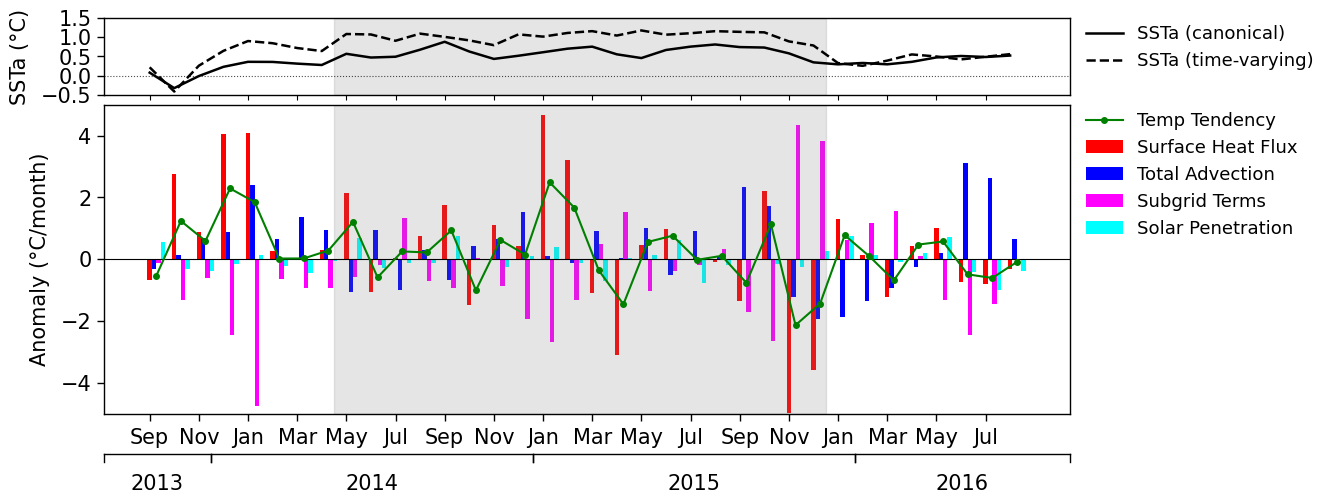

In [33]:
fig, (ax_sst, ax) = plt.subplots(2, 1,figsize=(14, 5.5),sharex=True,gridspec_kw={'height_ratios': [1, 4],'hspace': 0.05})

x = np.arange(len(viz_padded_times))
month_abbrevs = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

month_labels = [month_abbrevs[t.month - 1] for t in viz_padded_times.values]

detection_start_idx = int(np.where(viz_padded_times.values == blob_times.values[0])[0][0])
detection_end_idx = int(np.where(viz_padded_times.values == blob_times.values[-1])[0][0])

# TOP: SSTa
ax_sst.plot(x,ssta_for_viz.values,color='black',linewidth=1.8,linestyle='-',label='SSTa (canonical)',zorder=15) # fixed footprint
ax_sst.plot(x,tv_ssta_for_viz.values,color='black',linewidth=1.8,linestyle='--',label='SSTa (time-varying)',zorder=15) # time varying footprint
ax_sst.axhline(0,color='k',linewidth=0.8,linestyle=':',alpha=0.7)

# Blob detection period
ax_sst.axvspan(detection_start_idx - 0.5,detection_end_idx + 0.5,color='gray',alpha=0.2)

ax_sst.set_ylim(-0.5, 1.5)
ax_sst.set_yticks([-0.5,0,0.5,1.0,1.5])
ax_sst.set_ylabel('SSTa (°C)',fontsize=15,labelpad=8)
ax_sst.tick_params(axis='y',labelsize=15,width=1,length=5)
ax_sst.tick_params(axis='x',labelbottom=False)

# SSTa legend
ax_sst.legend(fontsize=13,loc='upper left',bbox_to_anchor=(1.01, 1.0),ncol=1,frameon=False,borderaxespad=0)

# BOTTOM: Heat Budget
width = 0.18
term_colors_viz = {'SHF_depth': 'red','TOT_ADV': 'blue','SUBGRID': 'magenta','QSW_3D': 'cyan'}
term_labels_viz = {'SHF_depth': 'Surface Heat Flux','TOT_ADV': 'Total Advection','SUBGRID': 'Subgrid Terms','QSW_3D': 'Solar Penetration'}

# Heat-budget bars
for i, term in enumerate(['SHF_depth','TOT_ADV','SUBGRID','QSW_3D']):
    ax.bar(x + i * width, fosi_hb_profile_viz[term].values,width,color=term_colors_viz[term],label=term_labels_viz[term])
# Temperature tendency
ax.plot(x + 1.5 * width,fosi_hb_profile_viz['TEND_TEMP'].values,color='green',marker='o',markersize=4,linewidth=1.5,label='Temp Tendency',zorder=10)

ax.axvspan(detection_start_idx - 0.5,detection_end_idx + 0.5,color='gray',alpha=0.2)
ax.axhline(0,color='k',linewidth=0.8)
ax.set_ylim(-5, 5)
ax.set_ylabel('Anomaly (°C/month)',fontsize=15,labelpad=8)
ax.tick_params(axis='y',labelsize=15,width=1,length=5)

# Sep, Nov, Jan, Mar, May, Jul, Sep, Nov, ...
month_tick_idx = [i for i, t in enumerate(viz_padded_times.values) if t.month in [1, 3, 5, 7, 9, 11]]
ax.set_xticks(month_tick_idx)
ax.set_xticklabels([month_labels[i] for i in month_tick_idx],fontsize=15,rotation=0,ha='center')
ax.tick_params(axis='x',labelsize=15,width=1,length=5,pad=5)

years = sorted(set(t.year for t in viz_padded_times.values))

year_bounds = {}
for year in years:
    # January index
    jan_idx = np.where(np.array([t.year == year and t.month == 1 for t in viz_padded_times.values]))[0]
    # December index
    dec_idx = np.where(np.array([t.year == year and t.month == 12 for t in viz_padded_times.values]))[0]
    if len(jan_idx) > 0:
        left = jan_idx[0] - 0.5
    else:
        year_idx = np.where(np.array([t.year == year for t in viz_padded_times.values]))[0]
        left = year_idx[0] - 0.5
    if len(dec_idx) > 0:
        right = dec_idx[-1] + 0.5
    else:
        year_idx = np.where(np.array([t.year == year for t in viz_padded_times.values]))[0]
        right = year_idx[-1] + 0.5
    year_bounds[year] = (left, right)

year_line_y = -0.13

ax.plot([0, 1],[year_line_y, year_line_y],transform=ax.transAxes,color='black',linewidth=1.0,clip_on=False,zorder=20)
x_min = -0.5
x_max = len(x) - 0.5
for year in years:
    left, right = year_bounds[year]
    center = (left + right) / 2
    center_axes = ((center - x_min)/ (x_max - x_min))

    ax.text(center_axes,year_line_y - 0.065,str(year),transform=ax.transAxes,ha='center',va='top',fontsize=15,clip_on=False)

for year in years:
    left, right = year_bounds[year]
    left_axes = ((left - x_min)/ (x_max - x_min))
    ax.plot([left_axes, left_axes],[year_line_y,year_line_y - 0.025],transform=ax.transAxes,color='black',linewidth=1.0,clip_on=False,zorder=20)
    right_axes = ((right - x_min)/ (x_max - x_min))
    ax.plot([right_axes, right_axes],[year_line_y,year_line_y - 0.025],transform=ax.transAxes,color='black',linewidth=1.0,clip_on=False,zorder=20)

ax.legend(fontsize=13,loc='upper left',bbox_to_anchor=(1.01, 1.0),ncol=1,frameon=False,borderaxespad=0)
for a in [ax_sst, ax]:
    for spine in a.spines.values():
        spine.set_linewidth(1)

plt.subplots_adjust(left=0.09,right=0.78,bottom=0.25,top=0.97,hspace=0.05)
plt.show()

In [39]:
lat_slice = slice(204, 367)
lon_slice = slice(190, 280)
NO_SEC_IN_1_MON = 2629740

# ============================================================
fosi_heat_budget = xr.open_dataset('/glade/derecho/scratch/cassiacai/fosi_heat_budget_155m.nc')
fosi_heat_budget['SUBGRID'] = fosi_heat_budget['TEND_TEMP'] - (
    fosi_heat_budget['TOTADV'] + fosi_heat_budget['SHF_depth'] + fosi_heat_budget['QSW_3D'])

fosi_hb_detrended = {}
for term in ['TOTADV', 'SHF_depth', 'QSW_3D', 'SUBGRID', 'TEND_TEMP']:
    notrend = detrend_term(fosi_heat_budget[term])
    key = 'TOT_ADV' if term == 'TOTADV' else term
    fosi_hb_detrended[key] = notrend

fosi_hb_cropped = {term: da.isel(nlat_t=lat_slice, nlon_t=lon_slice) for term, da in fosi_hb_detrended.items()}


# Canonical mask (POP grid)
mean_image_pop_files = [f'/glade/derecho/scratch/cassiacai/mean_image_{i}_POP.nc' for i in range(1, 8)]
mean_images_pop = [xr.open_dataset(file) for file in mean_image_pop_files]
masks_pop = [xr.where(image.__xarray_dataarray_variable__ > 0.1, 1, 0) for image in mean_images_pop]
NEPac_MHW_renamed_latlon = masks_pop[2].isel(nlat=lat_slice, nlon=lon_slice).rename({'nlat': 'nlat_t', 'nlon': 'nlon_t'})

fosi_hb_masked = {term: da.where(NEPac_MHW_renamed_latlon == 1) for term, da in fosi_hb_cropped.items()}


# FOSI Blob detection window + padded time window
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels
object_id = 94.0
blob_times = fosi_blobs.time.where((fosi_blobs == object_id).any(dim=('lat', 'lon')), drop=True)
print(f"n_months in blob_times: {len(blob_times)} -- VERIFY: 20")
padded_times_fosi = build_padded_time_window(fosi_hb_masked['TOT_ADV'].time, blob_times)


# Build the padded, area-averaged FOSI heat budget profile
fosi_hb_profile = {
    term: da.sel(time=padded_times_fosi).mean(dim=('nlat_t', 'nlon_t')).compute()
    for term, da in fosi_hb_masked.items()
}

print("fosi_hb_profile built:", list(fosi_hb_profile.keys()))
print({term: (float(ts.min()), float(ts.max())) for term, ts in fosi_hb_profile.items()})

n_months in blob_times: 20 -- VERIFY: 20
fosi_hb_profile built: ['TOT_ADV', 'SHF_depth', 'QSW_3D', 'SUBGRID', 'TEND_TEMP']
{'TOT_ADV': (-1.9189894364378537, 2.3374321488967467), 'SHF_depth': (-4.990679540345742, 4.663633052585285), 'QSW_3D': (-0.7715706456049386, 0.7638532699842709), 'SUBGRID': (-2.6647983800899517, 4.331895032176939), 'TEND_TEMP': (-2.1350142038697943, 2.4867183875509213)}


In [40]:
fosi_phases_5, fosi_n_phases, fosi_peak_date = phase_split_adaptive(fosi_hb_profile)

print(f"FOSI Blob: {fosi_n_phases}-phase decomposition")
print(f"Peak-tendency month: {fosi_peak_date}")
print("\nPhase averages (°C/month):")
for term in ['TEND_TEMP', 'TOT_ADV', 'SHF_depth', 'QSW_3D', 'SUBGRID']:
    print(f"\n{term}:")
    for phase in ['Pre-MHW', 'pre-peak', 'peak-tendency', 'post-peak', 'Post-MHW']:
        val = fosi_phases_5[term][phase]
        print(f"  {phase}: {val:.2f}" if not np.isnan(val) else f"  {phase}: undefined")

FOSI Blob: 5-phase decomposition
Peak-tendency month: 2015-01-15 00:00:00

Phase averages (°C/month):

TEND_TEMP:
  Pre-MHW: 0.15
  pre-peak: 0.22
  peak-tendency: 2.49
  post-peak: -0.18
  Post-MHW: 0.44

TOT_ADV:
  Pre-MHW: 1.17
  pre-peak: 0.14
  peak-tendency: 0.11
  post-peak: 0.30
  Post-MHW: -1.61

SHF_depth:
  Pre-MHW: 0.16
  pre-peak: 0.46
  peak-tendency: 4.66
  post-peak: -0.67
  Post-MHW: 0.72

QSW_3D:
  Pre-MHW: -0.24
  pre-peak: 0.10
  peak-tendency: 0.39
  post-peak: -0.10
  Post-MHW: 0.45

SUBGRID:
  Pre-MHW: -0.93
  pre-peak: -0.47
  peak-tendency: -2.66
  post-peak: 0.29
  Post-MHW: 0.89


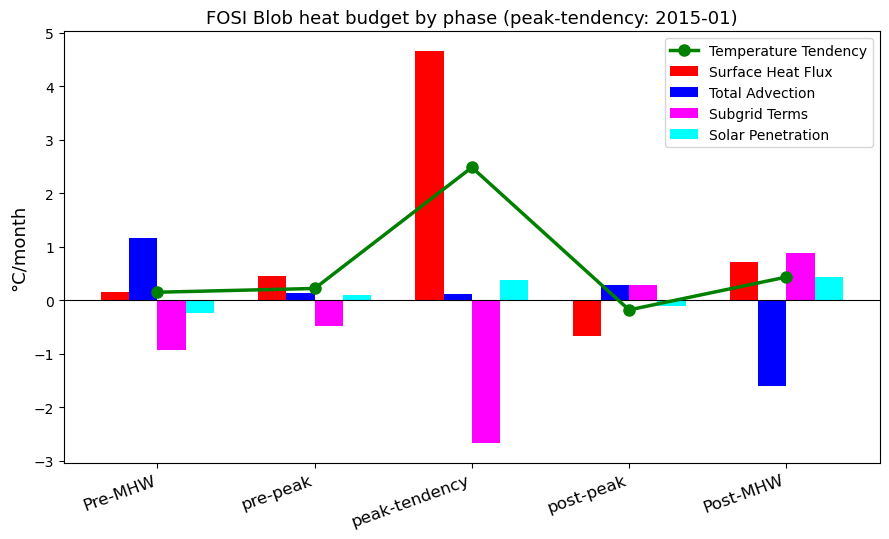

In [41]:
phase_names_5 = ['Pre-MHW', 'pre-peak', 'peak-tendency', 'post-peak', 'Post-MHW']
terms_to_plot = ['SHF_depth', 'TOT_ADV', 'SUBGRID', 'QSW_3D']
term_colors = {'SHF_depth': 'red', 'TOT_ADV': 'blue', 'SUBGRID': 'magenta', 'QSW_3D': 'cyan'}
term_labels = {'SHF_depth': 'Surface Heat Flux', 'TOT_ADV': 'Total Advection',
               'SUBGRID': 'Subgrid Terms', 'QSW_3D': 'Solar Penetration'}

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(phase_names_5))
width = 0.18

for i, term in enumerate(terms_to_plot):
    values = [fosi_phases_5[term][phase] for phase in phase_names_5]
    ax.bar(x + i * width, values, width, color=term_colors[term], label=term_labels[term])

tend_values = [fosi_phases_5['TEND_TEMP'][phase] for phase in phase_names_5]
ax.plot(x + 1.5 * width, tend_values, color='green', marker='o', markersize=8, linewidth=2.5,
        label='Temperature Tendency', zorder=10)

ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(phase_names_5, fontsize=12, rotation=20, ha='right')
ax.set_ylabel('°C/month', fontsize=13)
ax.set_title(f'FOSI Blob heat budget by phase (peak-tendency: {str(fosi_peak_date)[:7]})', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [44]:
phase_names = ['Pre-MHW','pre-peak','peak-tendency','post-peak','Post-MHW']
phase_time = fosi_hb_profile['TEND_TEMP'].time
tend_temp = fosi_hb_profile['TEND_TEMP']

blob_start_idx = int(np.where(phase_time.values == blob_times.values[0])[0][0])
blob_end_idx = int(np.where(phase_time.values == blob_times.values[-1])[0][0])

core_tend = tend_temp.isel(time=slice(blob_start_idx,blob_end_idx + 1))
peak_idx_within_blob = int(np.abs(core_tend.values).argmax())
peak_idx_global = (blob_start_idx +peak_idx_within_blob)
peak_date = phase_time.values[peak_idx_global]

print("\nPeak-tendency month:")
print(peak_date)
pre_post_months = 2
phase_indices = {'Pre-MHW': np.arange(blob_start_idx - pre_post_months,blob_start_idx),
                 'pre-peak': np.arange(blob_start_idx,peak_idx_global),
                 'peak-tendency': np.array([peak_idx_global]),
                 'post-peak': np.arange(peak_idx_global + 1,blob_end_idx + 1),
                 'Post-MHW': np.arange(blob_end_idx + 1,blob_end_idx + 1 + pre_post_months)}
ssta_phase_window = ssta_for_viz.sel(time=phase_time)
ssta_phase_data = {}
for phase in phase_names:
    indices = phase_indices[phase]
    ssta_phase_data[phase] = (ssta_phase_window.isel(time=indices).values)
    
terms_to_plot = ['SHF_depth','TOT_ADV','SUBGRID','QSW_3D']
term_colors = {'SHF_depth': 'red','TOT_ADV': 'blue','SUBGRID': 'magenta','QSW_3D': 'cyan'}
term_labels = {'SHF_depth': 'Surface Heat Flux','TOT_ADV': 'Total Advection','SUBGRID': 'Subgrid Terms','QSW_3D': 'Solar Penetration'}

tend_values = [fosi_phases_5['TEND_TEMP'][phase] for phase in phase_names]


Peak-tendency month:
2015-01-15 00:00:00


<>:7: SyntaxWarning: invalid decimal literal
<>:7: SyntaxWarning: invalid decimal literal
/glade/derecho/scratch/cassiacai/tmp/ipykernel_49348/2940598848.py:7: SyntaxWarning: invalid decimal literal
  violin_positions = [phase_names.index(phase) + 1for phase in violin_phases]


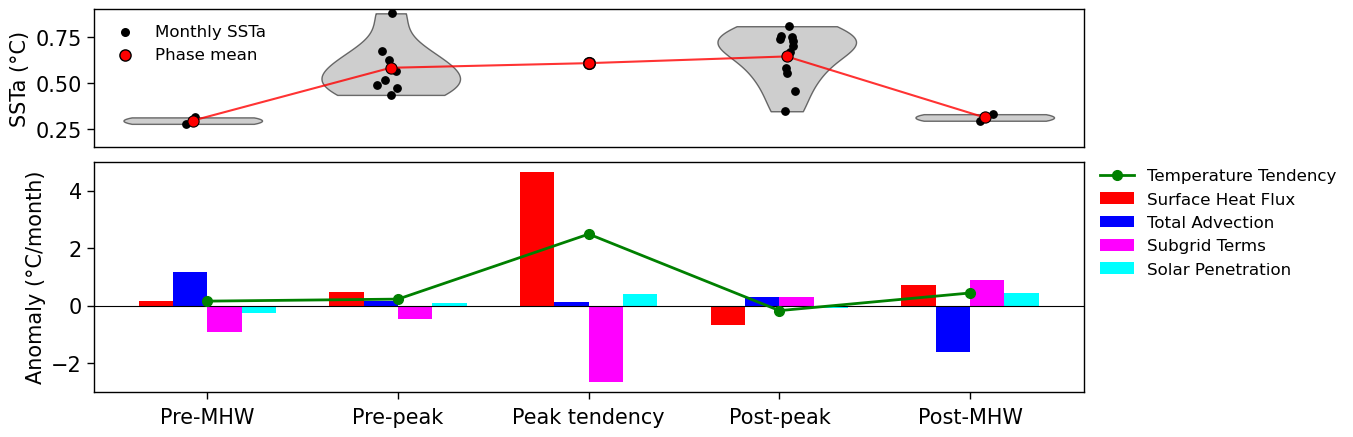

In [43]:
fig, (ax_sst, ax) = plt.subplots(2,1,figsize=(15, 4.5),gridspec_kw={'height_ratios': [1.5, 2.5],'hspace': 0.08})

# SSTa VIOLINS
x_phase = np.arange(len(phase_names))
violin_colors = ['0.65','0.65','none','0.65','0.65']
violin_phases = ['Pre-MHW','pre-peak','post-peak','Post-MHW']
violin_positions = [phase_names.index(phase) + 1for phase in violin_phases]
violin_data = [ssta_phase_data[phase]for phase in violin_phases]

parts = ax_sst.violinplot(violin_data,
    positions=violin_positions,widths=0.70,showmeans=False,showmedians=False,showextrema=False)

for body in parts['bodies']:
    body.set_facecolor('0.65')
    body.set_edgecolor('black')
    body.set_linewidth(1.0)
    body.set_alpha(0.55)

rng = np.random.default_rng(42)
for i, phase in enumerate(phase_names):
    values = ssta_phase_data[phase]
    if phase == 'peak-tendency':
        ax_sst.scatter(i + 1,values[0],color='black',s=75,edgecolor='black',linewidth=0.8,zorder=10)
    else:
        jitter = rng.normal(0,0.035,size=len(values))
        ax_sst.scatter(np.full(len(values), i + 1) + jitter,values,color='black',s=28,zorder=10)

for i, phase in enumerate(phase_names):
    values = ssta_phase_data[phase]
    mean_value = np.nanmean(values)
    ax_sst.scatter(i + 1,mean_value,color='red',s=65,marker='o',edgecolor='black',linewidth=0.8,zorder=15)

phase_means = [np.nanmean(ssta_phase_data[phase]) for phase in phase_names]

ax_sst.plot(np.arange(1, len(phase_names) + 1),phase_means,color='red',linewidth=1.5,alpha=0.8,zorder=12)
ax_sst.axhline(0,color='k',linewidth=0.8,linestyle=':',alpha=0.7)
ax_sst.set_ylim(0.15,0.9)
ax_sst.set_yticks([0.25, 0.5, 0.75])
ax_sst.set_ylabel('SSTa (°C)',fontsize=15)
ax_sst.tick_params(axis='y',labelsize=15,width=1,length=5)
ax_sst.set_xlim(0.5,5.5)
ax_sst.tick_params(axis='x',bottom=False,labelbottom=False)
ax_sst.scatter([],[],color='black',s=30,label='Monthly SSTa')
ax_sst.scatter([],[],color='red',s=65,edgecolor='black',label='Phase mean')
ax_sst.legend(fontsize=12,loc='upper left',frameon=False)

width = 0.18
for i, term in enumerate(terms_to_plot):
    values = [fosi_phases_5[term][phase] for phase in phase_names]
    ax.bar(x_phase + i * width,values,width,color=term_colors[term],label=term_labels[term])

ax.plot(x_phase + 1.5 * width,tend_values,color='green',marker='o',markersize=7,linewidth=2.0,label='Temperature Tendency',zorder=10)

ax.axhline(0,color='k',linewidth=0.8)
ax.set_xticks(x_phase + 1.5 * width)
ax.set_xticklabels(['Pre-MHW','Pre-peak','Peak tendency','Post-peak','Post-MHW'],fontsize=15)
ax.tick_params(axis='x',labelsize=15,width=1,length=5,pad=6)
ax.set_ylabel('Anomaly (°C/month)',fontsize=15)
ax.set_ylim(-3,5)
ax.tick_params(axis='y',labelsize=15,width=1,length=5)
ax.legend(fontsize=12,loc='upper left',bbox_to_anchor=(1.01, 1.0),frameon=False,ncol=1,borderaxespad=0)

for a in [ax_sst, ax]:
    for spine in a.spines.values():
        spine.set_linewidth(1.0)

plt.subplots_adjust(left=0.10,right=0.76,bottom=0.12,top=0.97,hspace=0.08)
plt.show()